## This notebook trains the classical model on the QQP dataset. The accuracy will be measured and stored for final performance comparisons

In [1]:
#Importing required packages
import os
import sys
import time
from pathlib import Path
from datetime import date

import joblib
import matplotlib.pyplot as plt
import pandas as pd

from sklearn.metrics import (
    ConfusionMatrixDisplay,
    RocCurveDisplay
)

sys.path.append(os.path.abspath(".."))

from src.classical_models import (
    combine_sentences,
    create_tfidf_vectorizer,
    vectorize_data,
    train_logistic_regression,
    predict,
    save_classical_model
)

from src.evaluate import (
    evaluate_classifier,
    compute_confusion_matrix
)

from src.utils import log_experiment

# 1. QQP

In [2]:
#Load the processed datasets
train = pd.read_csv("../datasets/processed/classical/qqp_train.csv")
validation = pd.read_csv("../datasets/processed/classical/qqp_validation.csv")
test = pd.read_csv("../datasets/processed/classical/qqp_test.csv")

In [3]:
#Overview
print("Training:", train.shape)
print("Validation:", validation.shape)
print("Test:", test.shape)

display(train.head())

print("\nMissing Values")
display(train.isnull().sum())

print("\nLabel Distribution")
display(train["label"].value_counts())

Training: (363846, 4)
Validation: (40430, 4)
Test: (390965, 4)


,question1,question2,label,idx
0,how is the life of a math student? could you d...,which level of prepration is enough for the ex...,0,0
1,how do i control my horny emotions?,how do you control your horniness?,1,1
2,what causes stool color to change to yellow?,what can cause stool to come out as little balls?,0,2
3,what can one do after mbbs?,what do i do after my mbbs ?,1,3
4,where can i find a power outlet for my laptop ...,"would a second airport in sydney, australia be...",0,4



Missing Values


question1    0
question2    2
label        0
idx          0
dtype: int64


Label Distribution


label
0    229468
1    134378
Name: count, dtype: int64

In [8]:
#Removing missing values
train = train.dropna(subset=["question1", "question2"])
validation = validation.dropna(subset=["question1", "question2"])
test = test.dropna(subset=["question1", "question2"])

In [9]:
#Combine Sentence Pairs
def combine_sentences(df):
    return (
        df["question1"]
        + " [SEP] "
        + df["question2"]
    )

In [10]:
X_train = combine_sentences(train)
X_validation = combine_sentences(validation)
X_test = combine_sentences(test)

y_train = train["label"]
y_validation = validation["label"]
y_test = test["label"]

In [11]:
#Define the TF-IDF Vectorizer
vectorizer = create_tfidf_vectorizer()

In [12]:
(
    X_train_vector,
    X_validation_vector,
    X_test_vector
) = vectorize_data(
    vectorizer,
    X_train,
    X_validation,
    X_test
)

In [13]:
#Training a Logistic Regression model
start_time = time.perf_counter()

model = train_logistic_regression(
    X_train_vector,
    y_train
)

end_time = time.perf_counter()

training_time = end_time - start_time

print(f"Training Time: {training_time:.4f} seconds")

Training Time: 3.1619 seconds


In [14]:
#Predictions
start_time = time.perf_counter()

predictions, probabilities = predict(
    model,
    X_validation_vector
)

end_time = time.perf_counter()

inference_time = end_time - start_time

print(f"Inference Time: {inference_time:.4f} seconds")

Inference Time: 0.0083 seconds


In [15]:
#Evaluation
metrics = evaluate_classifier(
    y_validation,
    predictions,
    probabilities
)

for metric, value in metrics.items():
    print(f"{metric}: {value:.4f}")

Accuracy: 0.7675
Precision: 0.7228
Recall: 0.5979
F1: 0.6544
ROC-AUC: 0.8364


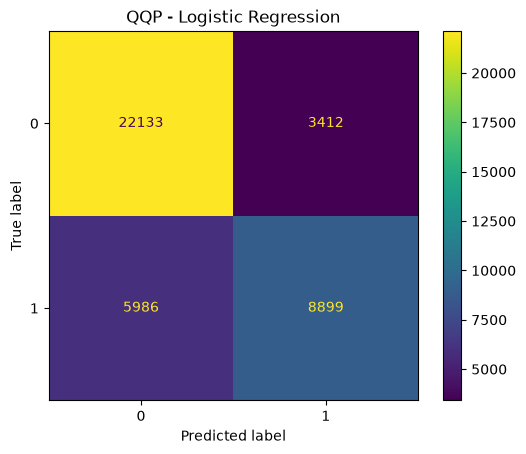

In [16]:
cm = compute_confusion_matrix(
    y_validation,
    predictions
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm
)

disp.plot()

plt.title("QQP - Logistic Regression")

plt.savefig(
    "../results/plots/qqp_confusion_matrix.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

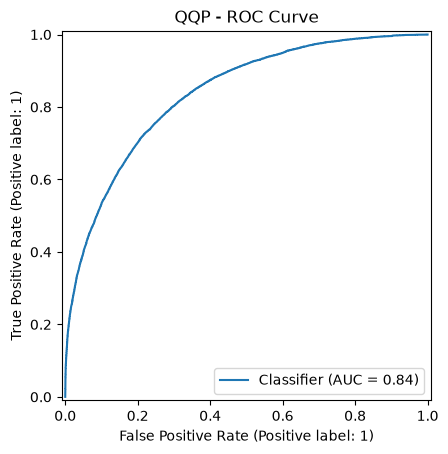

In [17]:
RocCurveDisplay.from_predictions(
    y_validation,
    probabilities
)

plt.title("QQP - ROC Curve")

plt.savefig(
    "../results/plots/qqp_roc_curve.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [18]:
#Saving the results
predictions_df = validation.copy()

predictions_df["prediction"] = predictions
predictions_df["probability"] = probabilities

predictions_df.to_csv(
    "../results/predictions/qqp_predictions.csv",
    index=False
)

predictions_df.head()

,question1,question2,label,idx,prediction,probability
0,why are african-americans so beautiful?,why are hispanics so beautiful?,0,0,0,0.266326
1,i want to pursue phd in computer science about...,i handle social media for a non-profit. should...,0,1,0,0.042048
2,is there a reason why we should travel alone?,what are some reasons to travel alone?,1,2,0,0.481027
3,why are people so obsessed with having a girlf...,how can a single male have a child?,0,3,0,0.285113
4,what are some good baby girl names starting wi...,what are some good baby girl names starting wi...,0,4,0,0.338266


In [20]:
#Saving the predictions
metrics_df = pd.DataFrame([metrics])

metrics_df.to_csv(
    "../results/metrics/qqp_logreg_metrics.csv",
    index=False
)

metrics_df

,Accuracy,Precision,Recall,F1,ROC-AUC
0,0.767549,0.722849,0.59785,0.654434,0.836436


In [21]:
#Saving the model
Path("../models/classical").mkdir(
    parents=True,
    exist_ok=True
)

save_classical_model(
    model,
    vectorizer,
    "../models/classical/qqp_logistic_regression.pkl",
    "../models/classical/qqp_tfidf_vectorizer.pkl"
)

print("Model saved successfully.")

Model saved successfully.


In [34]:
#Error Analysis
errors = predictions_df[
    predictions_df["label"] != predictions_df["prediction"]
]

print(f"Incorrect Predictions: {len(errors)}")

errors.head(20)

Incorrect Predictions: 111


,sentence1,sentence2,label,idx,prediction,probability
1,magnarelli said racicot hated the iraqi regime...,"his wife said he was "" 100 percent behind geor...",0,18,1,0.649710
4,no dates have been set for the civil or the cr...,no dates have been set for the criminal or civ...,0,33,1,0.628857
6,while dioxin levels in the environment were up...,the institute said dioxin levels in the enviro...,0,54,1,0.701684
11,""" sanitation is poor ... there could be typhoi...",""" sanitation is poor , drinking water is gener...",0,83,1,0.699066
19,the pound also made progress against the dolla...,the british pound flexed its muscle against th...,0,175,1,0.514979
22,"the driver , eugene rogers , helped to remove ...","at the accident scene , the driver was "" cover...",0,222,1,0.683913
26,cooley said he expects muhammad will similarly...,lee boyd malvo will be called as a witness wed...,0,284,1,0.699723
30,"with these assets , funny cide has a solid cha...",funny cide is looking to become horse racing '...,0,334,1,0.749794
35,"bush wanted "" to see an aircraft landing the s...","on tuesday , before byrd 's speech , fleischer...",0,374,1,0.828424
36,"on monday the palestinian prime minister , mah...",palestinian prime minister mahmoud abbas must ...,0,375,1,0.715886


In [22]:
#Logging the output
experiment = {
    "Experiment ID": "EXP-002",
    "Date": date.today().isoformat(),
    "Phase": "Baseline",
    "Model": "Logistic Regression",
    "Dataset": "QQP",
    "Train Split": len(train),
    "Validation Split": len(validation),
    "Test Split": len(test),
    "Batch Size": "N/A",
    "Learning Rate": "N/A",
    "Epochs": "N/A",
    "Accuracy": metrics["Accuracy"],
    "Precision": metrics["Precision"],
    "Recall": metrics["Recall"],
    "F1": metrics["F1"],
    "ROC-AUC": metrics["ROC-AUC"],
    "BLEU": "N/A",
    "ROUGE": "N/A",
    "BERTScore": "N/A",
    "Train Time": training_time,
    "Inference Time": inference_time,
    "Notes": "TF-IDF (1,2)-gram baseline",
    "Status": "Completed"
}

log_experiment(
    "../logs/experiments.xlsx",
    experiment
)

print("Experiment logged successfully.")

Experiment logged successfully.


In [23]:
#Summary
print("=" * 60)
print("QQP BASELINE COMPLETE")
print("=" * 60)

print(f"Accuracy      : {metrics['Accuracy']:.4f}")
print(f"Precision     : {metrics['Precision']:.4f}")
print(f"Recall        : {metrics['Recall']:.4f}")
print(f"F1 Score      : {metrics['F1']:.4f}")
print(f"ROC-AUC       : {metrics['ROC-AUC']:.4f}")
print(f"Training Time : {training_time:.4f} sec")
print(f"Inference Time: {inference_time:.4f} sec")

print("\nArtifacts Generated:")
print("- Model")
print("- Vectorizer")
print("- Metrics CSV")
print("- Predictions CSV")
print("- Confusion Matrix")
print("- ROC Curve")
print("- Experiment Log")

QQP BASELINE COMPLETE
Accuracy      : 0.7675
Precision     : 0.7228
Recall        : 0.5979
F1 Score      : 0.6544
ROC-AUC       : 0.8364
Training Time : 3.1619 sec
Inference Time: 0.0083 sec

Artifacts Generated:
- Model
- Vectorizer
- Metrics CSV
- Predictions CSV
- Confusion Matrix
- ROC Curve
- Experiment Log
